# Homework 1.1

In [24]:
# using deepseek API

# Create the API key here:
# https://platform.deepseek.com/api_keys

# Install the required library
!pip install -q -U openai

# install dotenv
!pip install -q python-dotenv

In [ ]:
from dotenv import load_dotenv
import os
from openai import OpenAI
import time
import json
from pathlib import Path
import uuid

load_dotenv()
api_key = os.getenv("DEEPSEEK_API_KEY")
client = OpenAI(
    api_key=api_key,
    base_url="https://api.deepseek.com"
)

print("Deepseek API initialized successfully")

Deepseek API initialized successfully


In [ ]:
# read all files in the articles directory
articles = {}
for path in Path("articles").glob("*.txt"):
    articles[path.name] = path.read_text()
        
print(f"Read {len(articles)} articles.")

Read 10 articles.


In [ ]:

# Tell the model to be a helpful assistant that summarizes articles. 
# Provide how you want the summary to be formatted.
instructions = """
You are a helpful assistant that summarizes articles.
Summarize the articles to a person who has not read them nor knows anything about them or the topic.
Output constraints:
- Output 5 bullet points.
- Each bullet point should be no more than 1-2 sentences long.
- Keep the sentences simple and easy to understand, avoiding technical jargon.
- One sentence should be no more than 20 words.
- Neutral tone, no opinions or assumptions.
- Output just the bullet points, no other text.
"""

def ask(text):
    """
    Sends article text to the DeepSeek API and returns a summarized response.
    """
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text}
        ],
        temperature=0.2,
    )
    return response.choices[0].message.content

summaries = {}
for filename, content in articles.items():
    print(f"Summarizing {filename}...")
    retries = 3
    TIMEOUT = 10
    while retries > 0:
        try:
            summaries[filename] = ask(content)
            time.sleep(0.5)
            print(f"Summarized {filename}.\n")
            break 
        except Exception as e:
            retries -= 1
            if retries > 0:
                print(
                    f"Error, retrying in {TIMEOUT} seconds... "
                    f"({retries} attempts left)"
                )
                time.sleep(TIMEOUT)
            else:
                print(f"Failed after retries: {filename}")
    
    

Summarizing wordpress.txt...
Summarized wordpress.txt.

Summarizing OSM.txt...
Summarized OSM.txt.

Summarizing wayback_machine.txt...
Summarized wayback_machine.txt.

Summarizing wikipedia.txt...
Summarized wikipedia.txt.

Summarizing chatoyancy.txt...
Summarized chatoyancy.txt.

Summarizing youtube.txt...
Summarized youtube.txt.

Summarizing 8086.txt...
Summarized 8086.txt.

Summarizing c_lang.txt...
Summarized c_lang.txt.

Summarizing annas_arch.txt...
Summarized annas_arch.txt.

Summarizing chatgpt.txt...
Summarized chatgpt.txt.



In [ ]:
# print all summaries
for filename, summary in summaries.items():
    print(f"Summary of {filename}:\n{summary}\n")
    
# save summaries as json file
with open("summaries.json", "w") as f:
    json.dump(summaries, f, indent=4)

Summary of wordpress.txt:
- WordPress is a free system for building websites and blogs.
- It started as a blog tool but now makes many types of websites.
- Users can change a site's design using themes and add features with plugins.
- It was created in 2003 and is very popular for building websites.
- To use it, you need to install it on a web server or hosting service.

Summary of OSM.txt:
- OpenStreetMap is a free map database created by volunteers.
- It started in 2004 because UK map data was not freely available.
- The project is supported by a non-profit foundation funded by donations.
- Many companies now use its data, especially after Google Maps introduced fees.
- The map stores locations using points, lines, and grouped relationships.

Summary of wayback_machine.txt:
- It is a free online archive of old websites.
- It was launched to the public in 2001.
- It saves copies of web pages as they change over time.
- Users can view how a website looked on a past date.
- It has archi

# Homework 1.2.2

In [ ]:
# In this one we will generate 1000 random numbers uniformly distributed between 0 and 1

NEEDED = 1000
BATCH_LIMIT = 100
TIMEOUT = 10
MAX_RETRIES = 3

def build_prompt(count: int, random_seed: str) -> str:
    """Build the prompt for random number generation."""
    return (
        f"Generate {count} random numbers uniformly distributed between 0 and 1.\n"
        f"Output as JSON: {{\"numbers\": [0.123, ...]}}\n"
        f"No markdown, no extra text. 3 decimal places of precision.\n"
        f"{random_seed}"
    )

def generate(count, random_seed):
    """
    Requests 'count' random numbers from the DeepSeek API.
    Returns the raw JSON string response from the model.
    """
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates random numbers."},
            {"role": "user", "content": build_prompt(count, random_seed)}
        ],
        temperature=2,
    )
    return response.choices[0].message.content

all_numbers = []
num_count = 0
iteration = 0
retries = 0
# Keep generating batches until we reach the total needed
while num_count < NEEDED:
    print(f"Generating numbers... ({num_count}/{NEEDED})")
    try:
        # Don't request more than the batch limit or what's remaining
        count = min(BATCH_LIMIT, NEEDED - num_count)
        # Use a random seed to ensure different numbers each time, but keep it consistent for retries
        # random_seed = f"Random noise seed: {uuid.uuid4()}"
        random_seed = ""
        print(f"-   Requesting {count} numbers")
        print(f"-   Using random seed: {random_seed}")
        
        # Generate the numbers with the model
        output = generate(count, random_seed)
        print(f"Output received: \n{output}")
        
        # Parse the JSON response from the model
        data = json.loads(output)
        numbers = data.get("numbers", []) # Extract the list of numbers or use an empty list if the key is missing
        all_numbers.append(numbers) # Store this batch
        num_count += len(numbers) # Update the running total
        print(f"Generated {len(numbers)} numbers.")
        
        retries = 0 
    except Exception as e:
        retries += 1
        if retries > MAX_RETRIES:
            print(f"Timeout generating numbers: {e}")
            break
        
        print(f"Error generating numbers: {e}")
        print(f"Retrying in {TIMEOUT} seconds...")
        time.sleep(TIMEOUT)

    print("-" * 40)

Generating numbers... (0/100)
-   Requesting 50 numbers
-   Using random seed: 
Output received: 
{
    "numbers": [
        0.382,
        0.917,
        0.174,
        0.619,
        0.759,
        0.041,
        0.890,
        0.204,
        0.785,
        0.436,
        0.223,
        0.661,
        0.128,
        0.996,
        0.583,
        0.741,
        0.197,
        0.324,
        0.598,
        0.489,
        0.005,
        0.452,
        0.850,
        0.111,
        0.980,
        0.357,
        0.024,
        0.733,
        0.303,
        0.569,
        0.891,
        0.214,
        0.814,
        0.701,
        0.926,
        0.450,
        0.077,
        0.278,
        0.632,
        0.543,
        0.862,
        0.490,
        0.185,
        0.672,
        0.093,
        0.407,
        0.766,
        0.293,
        0.527,
        0.610
    ]
}
Generated 50 numbers.
----------------------------------------
Generating numbers... (50/100)
-   Requesting 50 numbers
-   Us

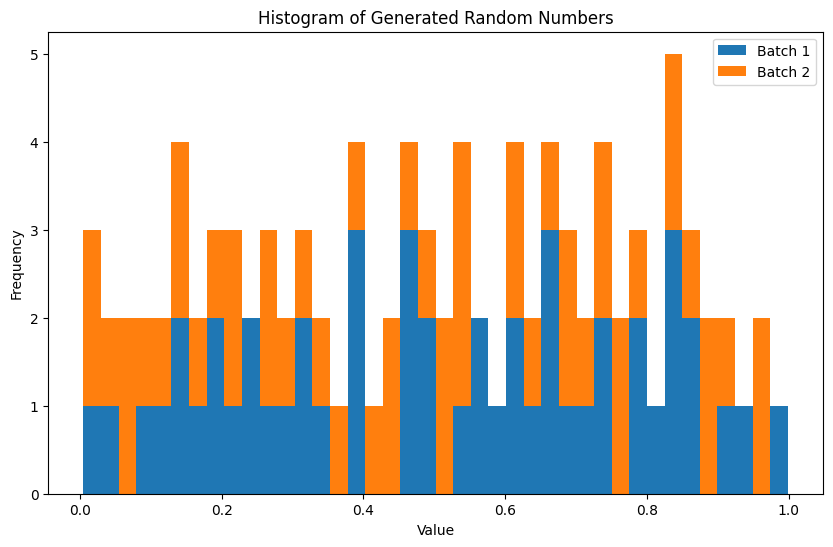

In [9]:
# Now plot them using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(all_numbers, bins=40, stacked=True, label=[f'Batch {i+1}' for i in range(len(all_numbers))])
plt.title('Histogram of Generated Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()